##  Imports 

In [21]:
# Cell 1: Imports

import os
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

import sys
import time
import random
import pickle
import gc
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import transforms
from torch.utils.data import Dataset, DataLoader

## GPU check

In [22]:
# Cell 2: Environment and GPU

print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("CUDA available:", torch.cuda.is_available())

if not torch.cuda.is_available():
    raise RuntimeError("Enable GPU in Kaggle settings.")

device = torch.device("cuda")

gpu_name = torch.cuda.get_device_name(0)
gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3

print("GPU:", gpu_name)
print(f"GPU memory: {gpu_memory:.2f} GB")

Python: 3.12.13
PyTorch: 2.10.0+cu128
CUDA: 12.8
CUDA available: True
GPU: Tesla T4
GPU memory: 14.56 GB


##  Reproducibility

In [23]:
# Cell 3: Reproducibility

SEED = 42

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    torch.use_deterministic_algorithms(True, warn_only=True)

seed_everything(SEED)

print("Seed:", SEED)
print("Deterministic mode enabled")

Seed: 42
Deterministic mode enabled


## Training setting

In [24]:
# Cell 4: Training settings

CONFIG = {
    "seed": 42,
    "num_classes": 10,
    "batch_size": 128,
    "max_epochs": 200,

    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 5e-4,
    "nesterov": True,

    "label_smoothing": 0.1,

    "warmup_epochs": 5,

    "plateau_factor": 0.5,
    "plateau_patience": 8,
    "minimum_lr": 1e-4,

    "early_stopping_patience": 20,

    "num_workers": 2,
    "mixed_precision": True,
    "recovery_save_every": 10
}

BATCH_SIZE = CONFIG["batch_size"]
MAX_EPOCHS = CONFIG["max_epochs"]

BASE_LR = CONFIG["learning_rate"]
MOMENTUM = CONFIG["momentum"]
WEIGHT_DECAY = CONFIG["weight_decay"]
NESTEROV = CONFIG["nesterov"]

WARMUP_EPOCHS = CONFIG["warmup_epochs"]

PLATEAU_FACTOR = CONFIG["plateau_factor"]
PLATEAU_PATIENCE = CONFIG["plateau_patience"]
MIN_LR = CONFIG["minimum_lr"]

PATIENCE = CONFIG["early_stopping_patience"]
NUM_WORKERS = CONFIG["num_workers"]

# Your exact Kaggle dataset path
DATA_ROOT = Path(
    "/kaggle/input/datasets/bindushreece/cifar-10-batches/"
    "cifar-10-batches-py/cifar-10-batches-py"
)

# Morning output names
OUTPUT_DIR = Path("/kaggle/working/teacher_resnet34")
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
RESULTS_DIR = OUTPUT_DIR / "results"

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

BEST_FULL_PATH = CHECKPOINT_DIR / "teacher_resnet34_best_full.pth"
BEST_WEIGHTS_PATH = CHECKPOINT_DIR / "teacher_resnet34_best_weights.pth"
RECOVERY_PATH = CHECKPOINT_DIR / "teacher_resnet34_recovery.pth"

for key, value in CONFIG.items():
    print(f"{key}: {value}")

print("\nDataset path:")
print(DATA_ROOT)

print("\nOutput path:")
print(OUTPUT_DIR)

seed: 42
num_classes: 10
batch_size: 128
max_epochs: 200
learning_rate: 0.1
momentum: 0.9
weight_decay: 0.0005
nesterov: True
label_smoothing: 0.1
warmup_epochs: 5
plateau_factor: 0.5
plateau_patience: 8
minimum_lr: 0.0001
early_stopping_patience: 20
num_workers: 2
mixed_precision: True
recovery_save_every: 10

Dataset path:
/kaggle/input/datasets/bindushreece/cifar-10-batches/cifar-10-batches-py/cifar-10-batches-py

Output path:
/kaggle/working/teacher_resnet34


##  Check dataset path

In [25]:
# Cell 5: Check CIFAR-10 files

required_files = [
    "data_batch_1",
    "data_batch_2",
    "data_batch_3",
    "data_batch_4",
    "data_batch_5",
    "test_batch"
]

for name in required_files:
    path = DATA_ROOT / name
    print(name, "->", path.exists())

assert all((DATA_ROOT / name).exists() for name in required_files)

print("\nCIFAR-10 files found correctly")

data_batch_1 -> True
data_batch_2 -> True
data_batch_3 -> True
data_batch_4 -> True
data_batch_5 -> True
test_batch -> True

CIFAR-10 files found correctly


## Load Cifar-10 

In [26]:
# Cell 6: Load CIFAR-10

def load_cifar_batch(path):
    with open(path, "rb") as f:
        batch = pickle.load(f, encoding="latin1")

    data = batch["data"]
    labels = batch["labels"]

    images = np.array(data)
    labels = np.array(labels, dtype=np.int64)

    images = images.reshape(-1, 3, 32, 32)
    images = images.transpose(0, 2, 3, 1)

    return images, labels


train_images = []
train_labels = []

for i in range(1, 6):
    images, labels = load_cifar_batch(
        DATA_ROOT / f"data_batch_{i}"
    )

    train_images.append(images)
    train_labels.append(labels)

X_train_full = np.concatenate(train_images)
y_train_full = np.concatenate(train_labels)

X_test, y_test = load_cifar_batch(
    DATA_ROOT / "test_batch"
)

print("Full training:", X_train_full.shape)
print("Training labels:", y_train_full.shape)

print("Test:", X_test.shape)
print("Test labels:", y_test.shape)

print("\nTraining class counts:")
print(np.bincount(y_train_full))

print("\nTest class counts:")
print(np.bincount(y_test))

Full training: (50000, 32, 32, 3)
Training labels: (50000,)
Test: (10000, 32, 32, 3)
Test labels: (10000,)

Training class counts:
[5000 5000 5000 5000 5000 5000 5000 5000 5000 5000]

Test class counts:
[1000 1000 1000 1000 1000 1000 1000 1000 1000 1000]


 ## Stratified 45k / 5k split

In [27]:
# Cell 7: Stratified split

rng = np.random.default_rng(SEED)

train_indices = []
val_indices = []

for class_id in range(10):
    indices = np.where(y_train_full == class_id)[0]
    rng.shuffle(indices)

    val_indices.extend(indices[:500])
    train_indices.extend(indices[500:])

train_indices = np.array(train_indices)
val_indices = np.array(val_indices)

rng.shuffle(train_indices)
rng.shuffle(val_indices)

X_train = X_train_full[train_indices]
y_train = y_train_full[train_indices]

X_val = X_train_full[val_indices]
y_val = y_train_full[val_indices]

overlap = np.intersect1d(train_indices, val_indices)

assert len(X_train) == 45000
assert len(X_val) == 5000
assert len(X_test) == 10000
assert len(overlap) == 0

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("\nTrain classes:")
print(np.bincount(y_train))

print("\nValidation classes:")
print(np.bincount(y_val))

print("\nTrain/validation overlap:", len(overlap))

Train: (45000, 32, 32, 3)
Validation: (5000, 32, 32, 3)
Test: (10000, 32, 32, 3)

Train classes:
[4500 4500 4500 4500 4500 4500 4500 4500 4500 4500]

Validation classes:
[500 500 500 500 500 500 500 500 500 500]

Train/validation overlap: 0


## Cutout Augmentation

In [28]:
# Cell 8: Cutout augmentation

class Cutout:
    def __init__(self, size=8):
        self.size = size

    def __call__(self, img):
        h, w = img.shape[1], img.shape[2]

        y = torch.randint(0, h, (1,)).item()
        x = torch.randint(0, w, (1,)).item()

        half = self.size // 2

        y1 = max(0, y - half)
        y2 = min(h, y + half)

        x1 = max(0, x - half)
        x2 = min(w, x + half)

        img[:, y1:y2, x1:x2] = 0

        return img

## Image transforms

In [29]:
# Cell 9: Image preprocessing

CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    Cutout(size=8),
    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        CIFAR10_MEAN,
        CIFAR10_STD
    )
])

print("Training transform:")
print(train_transform)

print("\nValidation/Test transform:")
print(eval_transform)

Training transform:
Compose(
    RandomCrop(size=(32, 32), padding=4)
    RandomHorizontalFlip(p=0.5)
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)

Validation/Test transform:
Compose(
    ToTensor()
    Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.247, 0.2435, 0.2616))
)


## Dataset and DataLoaders

In [30]:
# Cell 10: Dataset and DataLoaders

class CIFARArrayDataset(Dataset):
    def __init__(self, images, labels, transform):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, index):
        image = Image.fromarray(self.images[index])
        label = int(self.labels[index])

        image = self.transform(image)

        return image, label


train_dataset = CIFARArrayDataset(
    X_train, y_train, train_transform
)

val_dataset = CIFARArrayDataset(
    X_val, y_val, eval_transform
)

test_dataset = CIFARArrayDataset(
    X_test, y_test, eval_transform
)


def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32

    np.random.seed(worker_seed)
    random.seed(worker_seed)


generator = torch.Generator()
generator.manual_seed(SEED)


train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=NUM_WORKERS > 0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

Training batches: 352
Validation batches: 40
Test batches: 79


## Data sanity check


In [31]:
# Cell 11: Check one batch

images, labels = next(iter(train_loader))

print("Images:", images.shape)
print("Labels:", labels.shape)

print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

print("Image min:", images.min().item())
print("Image max:", images.max().item())

Images: torch.Size([128, 3, 32, 32])
Labels: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64
Image min: -1.9894737005233765
Image max: 2.12648868560791


## Resnet Basic Block

In [32]:
# Cell 12: ResNet BasicBlock

class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(
                    in_channels,
                    out_channels,
                    kernel_size=1,
                    stride=stride,
                    bias=False
                ),
                nn.BatchNorm2d(out_channels)
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out += identity
        out = self.relu(out)

        return out

## CIFAR-10 ResNet34

In [33]:
# Cell 13: CIFAR-10 ResNet34

class CIFAR10ResNet34(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(
            3,
            64,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False
        )

        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)

        self.layer1 = self._make_layer(
            64, blocks=3, stride=1
        )

        self.layer2 = self._make_layer(
            128, blocks=4, stride=2
        )

        self.layer3 = self._make_layer(
            256, blocks=6, stride=2
        )

        self.layer4 = self._make_layer(
            512, blocks=3, stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Linear(
            512,
            num_classes
        )

    def _make_layer(self, out_channels, blocks, stride):
        layers = []

        layers.append(
            BasicBlock(
                self.in_channels,
                out_channels,
                stride
            )
        )

        self.in_channels = out_channels

        for _ in range(1, blocks):
            layers.append(
                BasicBlock(
                    out_channels,
                    out_channels,
                    stride=1
                )
            )

        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)

        return self.fc(x)

## Create and check model

In [34]:
# Cell 14: Create ResNet34

model = CIFAR10ResNet34(
    num_classes=CONFIG["num_classes"]
).to(device)

total_params = sum(
    p.numel() for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

dummy = torch.randn(
    4, 3, 32, 32,
    device=device
)

with torch.no_grad():
    output = model(dummy)

print("Input:", dummy.shape)
print("Output:", output.shape)

assert output.shape == (4, 10)

Total parameters: 21,282,122
Trainable parameters: 21,282,122
Input: torch.Size([4, 3, 32, 32])
Output: torch.Size([4, 10])


##  Loss, optimizer and scheduler

In [35]:
# Cell 15: Loss, optimizer and scheduler

criterion = nn.CrossEntropyLoss(
    label_smoothing=CONFIG["label_smoothing"]
)

optimizer = optim.SGD(
    model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=NESTEROV
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=PLATEAU_FACTOR,
    patience=PLATEAU_PATIENCE,
    min_lr=MIN_LR
)

USE_AMP = (
    CONFIG["mixed_precision"]
    and device.type == "cuda"
)

scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

print("Loss: CrossEntropyLoss")
print("Label smoothing:", CONFIG["label_smoothing"])

print("Optimizer: SGD")
print("Base LR:", BASE_LR)
print("Momentum:", MOMENTUM)
print("Nesterov:", NESTEROV)
print("Weight decay:", WEIGHT_DECAY)

print("Warmup epochs:", WARMUP_EPOCHS)

print("Scheduler: ReduceLROnPlateau")
print("Scheduler patience:", PLATEAU_PATIENCE)
print("Scheduler factor:", PLATEAU_FACTOR)
print("Minimum LR:", MIN_LR)

print("Early stopping patience:", PATIENCE)
print("AMP:", USE_AMP)

Loss: CrossEntropyLoss
Label smoothing: 0.1
Optimizer: SGD
Base LR: 0.1
Momentum: 0.9
Nesterov: True
Weight decay: 0.0005
Warmup epochs: 5
Scheduler: ReduceLROnPlateau
Scheduler patience: 8
Scheduler factor: 0.5
Minimum LR: 0.0001
Early stopping patience: 20
AMP: True


## Short GPU speed check

In [36]:
# Cell 16: Short GPU speed check

benchmark_model = CIFAR10ResNet34().to(device)

benchmark_optimizer = optim.SGD(
    benchmark_model.parameters(),
    lr=BASE_LR,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY,
    nesterov=NESTEROV
)

benchmark_scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)

iterator = iter(train_loader)

warmup_batches = 5
timed_batches = 20

benchmark_model.train()
start = None

for i in range(warmup_batches + timed_batches):
    inputs, targets = next(iterator)

    inputs = inputs.to(device, non_blocking=True)
    targets = targets.to(device, non_blocking=True)

    benchmark_optimizer.zero_grad(set_to_none=True)

    if i == warmup_batches:
        torch.cuda.synchronize()
        start = time.perf_counter()

    with torch.autocast(
        device_type="cuda",
        dtype=torch.float16,
        enabled=USE_AMP
    ):
        outputs = benchmark_model(inputs)
        loss = criterion(outputs, targets)

    benchmark_scaler.scale(loss).backward()
    benchmark_scaler.step(benchmark_optimizer)
    benchmark_scaler.update()

torch.cuda.synchronize()

elapsed = time.perf_counter() - start

seconds_per_batch = elapsed / timed_batches
estimated_epoch = seconds_per_batch * len(train_loader)

print("GPU:", gpu_name)
print(f"Batch time: {seconds_per_batch:.4f} sec")
print(f"Estimated training part/epoch: {estimated_epoch:.1f} sec")

del benchmark_model
del benchmark_optimizer
del benchmark_scaler

gc.collect()
torch.cuda.empty_cache()

GPU: Tesla T4
Batch time: 0.0922 sec
Estimated training part/epoch: 32.4 sec


##  Training function

In [37]:
# Cell 17: Train one epoch

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for inputs, targets in loader:
        inputs = inputs.to(
            device,
            non_blocking=True
        )

        targets = targets.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=USE_AMP
        ):
            outputs = model(inputs)

            loss = criterion(
                outputs,
                targets
            )

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        batch_size = inputs.size(0)

        total_loss += loss.item() * batch_size

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == targets
        ).sum().item()

        total += batch_size

    epoch_loss = total_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

## Evaluation function

In [38]:
# Cell 18: Evaluate model

def evaluate(
    model,
    loader,
    criterion,
    use_amp=False
):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.inference_mode():
        for inputs, targets in loader:
            inputs = inputs.to(
                device,
                non_blocking=True
            )

            targets = targets.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=use_amp
            ):
                outputs = model(inputs)

                loss = criterion(
                    outputs,
                    targets
                )

            batch_size = inputs.size(0)

            total_loss += loss.item() * batch_size

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == targets
            ).sum().item()

            total += batch_size

    epoch_loss = total_loss / total
    epoch_accuracy = 100.0 * correct / total

    return epoch_loss, epoch_accuracy

## Checkpoint function


In [39]:
# Cell 19: Save full checkpoint

def save_checkpoint(
    path,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    best_val_accuracy,
    history
):
    checkpoint = {
        "model_name": "CIFAR10_ResNet34_Teacher",
        "epoch": epoch,
        "best_val_accuracy": best_val_accuracy,

        "model_state_dict": model.state_dict(),

        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "scaler_state_dict": scaler.state_dict(),

        "history": history,
        "config": CONFIG,

        "seed": SEED,
        "pytorch_version": torch.__version__,
        "cuda_version": torch.version.cuda,
        "gpu": gpu_name
    }

    torch.save(
        checkpoint,
        path
    )

##  Train ResNet34 teacher

In [40]:
# Cell 20: Train ResNet34 teacher

history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "learning_rate": [],
    "epoch_time_seconds": []
}

best_val_accuracy = -float("inf")
best_epoch = 0
epochs_without_improvement = 0

training_start = time.perf_counter()
warmup_wall_time = 0.0

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.perf_counter()

    # Linear warmup for first 5 epochs
    if epoch <= WARMUP_EPOCHS:
        warmup_lr = BASE_LR * (
            epoch / WARMUP_EPOCHS
        )

        for group in optimizer.param_groups:
            group["lr"] = warmup_lr

    current_lr = optimizer.param_groups[0]["lr"]

    # Train
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        scaler
    )

    # Validate
    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        use_amp=USE_AMP
    )

    epoch_time = time.perf_counter() - epoch_start

    if epoch <= WARMUP_EPOCHS:
        warmup_wall_time += epoch_time

    # Save history
    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_accuracy"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_acc)
    history["learning_rate"].append(current_lr)
    history["epoch_time_seconds"].append(epoch_time)

    # Save best validation model
    improved = val_acc > best_val_accuracy

    if improved:
        best_val_accuracy = val_acc
        best_epoch = epoch
        epochs_without_improvement = 0

        save_checkpoint(
            BEST_FULL_PATH,
            model,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_val_accuracy,
            history
        )

        torch.save(
            model.state_dict(),
            BEST_WEIGHTS_PATH
        )

    else:
        epochs_without_improvement += 1

    # Reduce LR only after warmup
    if epoch > WARMUP_EPOCHS:
        scheduler.step(val_loss)

    # Recovery file every 10 epochs
    if epoch % CONFIG["recovery_save_every"] == 0:
        save_checkpoint(
            RECOVERY_PATH,
            model,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_val_accuracy,
            history
        )

    # Epoch output
    print(
        f"epoch {epoch:03d}/{MAX_EPOCHS} | "
        f"lr {current_lr:.6f} | "
        f"train loss {train_loss:.4f} | "
        f"train acc {train_acc:.2f}% | "
        f"val loss {val_loss:.4f} | "
        f"val acc {val_acc:.2f}% | "
        f"best {best_val_accuracy:.2f}% | "
        f"wait {epochs_without_improvement}/{PATIENCE} | "
        f"time {epoch_time:.1f}s"
    )

    if improved:
        print(
            f"best model saved with validation accuracy "
            f"{best_val_accuracy:.2f}%"
        )

    if epoch == WARMUP_EPOCHS:
        print(
            f"\n5-epoch warmup completed"
            f"\nfirst {WARMUP_EPOCHS} epochs wall time: "
            f"{warmup_wall_time/60:.2f} minutes"
            f"\nReduceLROnPlateau is now active\n"
        )

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print("\nearly stopping triggered")
        print(f"stopped at epoch: {epoch}")
        print(f"best epoch: {best_epoch}")
        print(
            f"best validation accuracy: "
            f"{best_val_accuracy:.2f}%"
        )

        save_checkpoint(
            RECOVERY_PATH,
            model,
            optimizer,
            scheduler,
            scaler,
            epoch,
            best_val_accuracy,
            history
        )

        break

# Save final recovery state
save_checkpoint(
    RECOVERY_PATH,
    model,
    optimizer,
    scheduler,
    scaler,
    epoch,
    best_val_accuracy,
    history
)

total_training_time = (
    time.perf_counter()
    - training_start
)

print("\ntraining finished")
print(f"final epoch: {epoch}")
print(f"best epoch: {best_epoch}")
print(
    f"best validation accuracy: "
    f"{best_val_accuracy:.2f}%"
)
print(
    f"first {WARMUP_EPOCHS} epochs wall time: "
    f"{warmup_wall_time/60:.2f} min"
)
print(
    f"total training time: "
    f"{total_training_time/3600:.2f} hours"
)

epoch 001/200 | lr 0.020000 | train loss 1.7489 | train acc 42.20% | val loss 1.5945 | val acc 53.38% | best 53.38% | wait 0/20 | time 34.9s
best model saved with validation accuracy 53.38%
epoch 002/200 | lr 0.040000 | train loss 1.4208 | train acc 58.10% | val loss 1.4025 | val acc 60.06% | best 60.06% | wait 0/20 | time 34.7s
best model saved with validation accuracy 60.06%
epoch 003/200 | lr 0.060000 | train loss 1.2518 | train acc 66.49% | val loss 1.2955 | val acc 65.74% | best 65.74% | wait 0/20 | time 34.4s
best model saved with validation accuracy 65.74%
epoch 004/200 | lr 0.080000 | train loss 1.1333 | train acc 72.18% | val loss 1.1048 | val acc 73.18% | best 73.18% | wait 0/20 | time 34.6s
best model saved with validation accuracy 73.18%
epoch 005/200 | lr 0.100000 | train loss 1.0582 | train acc 75.44% | val loss 1.1299 | val acc 72.66% | best 73.18% | wait 1/20 | time 34.7s

5-epoch warmup completed
first 5 epochs wall time: 2.89 minutes
ReduceLROnPlateau is now active

e

##  Save training history

In [41]:
# Cell 21: Save training history

history_df = pd.DataFrame(history)

history_path = (
    RESULTS_DIR
    / "teacher_training_history.csv"
)

history_df.to_csv(
    history_path,
    index=False
)

display(history_df.tail())

print("Saved:", history_path)

,epoch,train_loss,train_accuracy,val_loss,val_accuracy,learning_rate,epoch_time_seconds
125,126,0.503799,99.877778,0.621551,95.90,0.000781,33.893879
126,127,0.504292,99.846667,0.621378,95.62,0.000781,33.837125
127,128,0.503627,99.886667,0.622244,95.68,0.000391,33.860161
128,129,0.503778,99.880000,0.619030,95.80,0.000391,33.829471
129,130,0.503637,99.880000,0.618070,95.84,0.000391,33.902288


Saved: /kaggle/working/teacher_resnet34/results/teacher_training_history.csv


## Accuracy curve

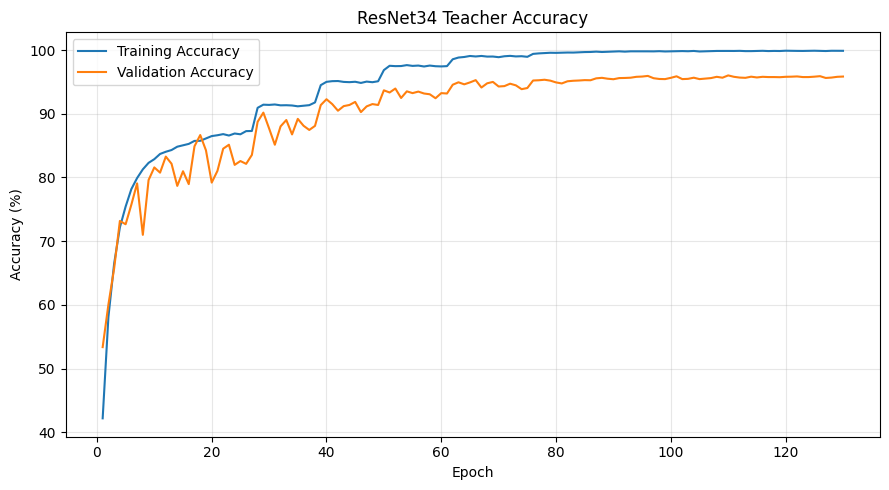

Saved: /kaggle/working/teacher_resnet34/results/teacher_accuracy_curve.png


In [42]:
# Cell 22: Accuracy curve

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_df["epoch"],
    history_df["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("ResNet34 Teacher Accuracy")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "teacher_accuracy_curve.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

## Loss Curve

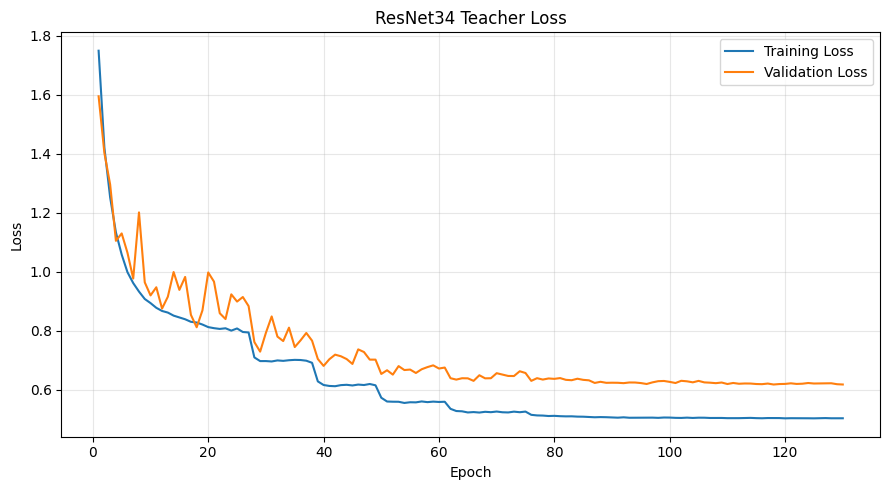

Saved: /kaggle/working/teacher_resnet34/results/teacher_loss_curve.png


In [43]:
# Cell 23: Loss curve

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Training Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet34 Teacher Loss")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "teacher_loss_curve.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

## Learning rate curve

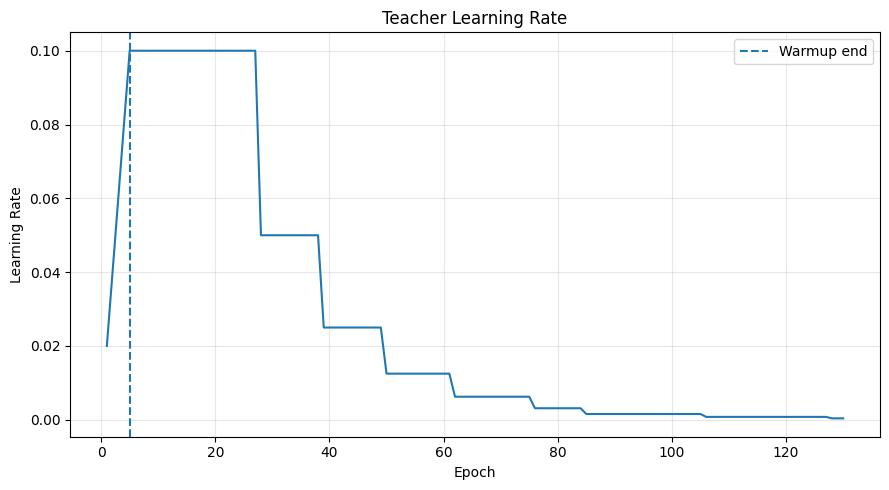

Saved: /kaggle/working/teacher_resnet34/results/teacher_learning_rate_curve.png


In [44]:
# Cell 24: Learning-rate curve

plt.figure(figsize=(9, 5))

plt.plot(
    history_df["epoch"],
    history_df["learning_rate"]
)

plt.axvline(
    WARMUP_EPOCHS,
    linestyle="--",
    label="Warmup end"
)

plt.xlabel("Epoch")
plt.ylabel("Learning Rate")
plt.title("Teacher Learning Rate")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

path = RESULTS_DIR / "teacher_learning_rate_curve.png"

plt.savefig(
    path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", path)

##  Verify saved best checkpoint

In [45]:
# Cell 25: Verify best checkpoint

best_checkpoint = torch.load(
    BEST_FULL_PATH,
    map_location="cpu",
    weights_only=False
)

best_weights = torch.load(
    BEST_WEIGHTS_PATH,
    map_location="cpu",
    weights_only=True
)

full_weights = best_checkpoint["model_state_dict"]

assert full_weights.keys() == best_weights.keys()

for key in full_weights:
    assert torch.equal(
        full_weights[key],
        best_weights[key]
    )

print("Full and weights-only checkpoints match")

fresh_teacher = CIFAR10ResNet34(
    num_classes=10
)

fresh_teacher.load_state_dict(
    best_weights
)

fresh_teacher = fresh_teacher.to(device)

val_loss_fp32, val_acc_fp32 = evaluate(
    fresh_teacher,
    val_loader,
    criterion,
    use_amp=False
)

print("Fresh teacher loaded correctly")
print("Best epoch:", best_checkpoint["epoch"])
print(
    f"Saved validation accuracy: "
    f"{best_checkpoint['best_val_accuracy']:.2f}%"
)

print(
    f"Reloaded validation accuracy: "
    f"{val_acc_fp32:.2f}%"
)

Full and weights-only checkpoints match
Fresh teacher loaded correctly
Best epoch: 110
Saved validation accuracy: 96.02%
Reloaded validation accuracy: 96.02%


## Test evaluation

In [46]:
# Cell 26: Official test evaluation

test_start = time.perf_counter()

test_loss, test_accuracy = evaluate(
    fresh_teacher,
    test_loader,
    criterion,
    use_amp=False
)

test_time = time.perf_counter() - test_start

print("=" * 60)
print("Resnet34 teacher result")
print("=" * 60)

print(
    f"Best epoch: "
    f"{best_checkpoint['epoch']}"
)

print(
    f"Best validation accuracy: "
    f"{best_checkpoint['best_val_accuracy']:.2f}%"
)

print(
    f"Test loss: "
    f"{test_loss:.4f}"
)

print(
    f"Test accuracy: "
    f"{test_accuracy:.2f}%"
)

print(
    f"Test time: "
    f"{test_time:.2f} seconds"
)

print("=" * 60)

Resnet34 teacher result
Best epoch: 110
Best validation accuracy: 96.02%
Test loss: 0.6339
Test accuracy: 95.05%
Test time: 4.72 seconds


## Store final test result

In [47]:
# Cell 27: Store official results

best_checkpoint["official_test_loss"] = test_loss
best_checkpoint["official_test_accuracy"] = test_accuracy

best_checkpoint[
    "total_training_time_seconds"
] = total_training_time

best_checkpoint[
    "warmup_wall_time_seconds"
] = warmup_wall_time

torch.save(
    best_checkpoint,
    BEST_FULL_PATH
)

print("Final results stored in:")
print(BEST_FULL_PATH)

Final results stored in:
/kaggle/working/teacher_resnet34/checkpoints/teacher_resnet34_best_full.pth


## Show .pth files

In [48]:
# Cell 28: Show teacher checkpoints

pth_files = sorted(
    CHECKPOINT_DIR.glob("*.pth")
)

for file in pth_files:
    size_mb = file.stat().st_size / 1024**2

    print(
        f"{file.name:<45}"
        f"{size_mb:.2f} MB"
    )

teacher_resnet34_best_full.pth               162.54 MB
teacher_resnet34_best_weights.pth            81.32 MB
teacher_resnet34_recovery.pth                162.55 MB


##  Zip all .pth files

In [49]:
# Cell 29: Zip teacher checkpoints

ZIP_PATH = Path(
    "/kaggle/working/resnet34_teacher_pth_files.zip"
)

pth_files = sorted(
    CHECKPOINT_DIR.glob("*.pth")
)

if not pth_files:
    raise RuntimeError("No .pth files found")

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    allowZip64=True
) as zip_file:

    for file in pth_files:
        zip_file.write(
            file,
            arcname=file.name
        )

        print("Added:", file.name)

zip_size = (
    ZIP_PATH.stat().st_size
    / 1024**2
)

print("\nZIP created successfully")
print("Path:", ZIP_PATH)
print(f"Size: {zip_size:.2f} MB")

Added: teacher_resnet34_best_full.pth
Added: teacher_resnet34_best_weights.pth
Added: teacher_resnet34_recovery.pth

ZIP created successfully
Path: /kaggle/working/resnet34_teacher_pth_files.zip
Size: 378.24 MB
